<a href="https://colab.research.google.com/github/dai-fujiden/boite-a-jouets/blob/main/phono_chine/Zhongwen_yinjie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Visit the website  Unicode https://home.unicode.org/

### 2. Unihan database explanation  https://www.unicode.org/reports/tr38/ . Reach the hyperlinked text, the UCD (the Unicode Character Database).


### 3. search the following texts using `ctrl+F` and click here.
```
Unihan Database
Latest version:
https://www.unicode.org/Public/UCD/latest/ucd/Unihan.zip
Version 17.0.0:
https://www.unicode.org/Public/17.0.0/ucd/Unihan.zip
```

### 4. Download frequency data
https://lingua.mtsu.edu/chinese-computing/statistics/index.html?utm_source=chatgpt.com


In [560]:
!pip install japanize-matplotlib
!pip install pykakasi

In [561]:
!git clone https://github.com/cmu-llab/wikihan.git

!git clone https://github.com/unicode-org/unihan-database.git

fatal: destination path 'wikihan' already exists and is not an empty directory.
fatal: destination path 'unihan-database' already exists and is not an empty directory.


In [605]:
import pandas as pd
import re

def parse_unihan_file(file_path, target_tags):
    """
    Unihanテキストファイルを読み込み、指定したタグのデータを辞書に整理する関数
    """
    data_dict = {}

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # コメント行や空行はスキップ
            if line.startswith('#') or not line.strip():
                continue

            # タブ区切りで分割
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue

            raw_code, tag, value = parts[0], parts[1], parts[2]

            # 前後の余計なスペースや文字を分離し、純粋なUnicode(例: U+3400)を取得
            code = raw_code.split()[0]

            if tag in target_tags:
                if code not in data_dict:
                    data_dict[code] = {}

                # 1. 日本語の読み(kJapanese)は、最初の1つだけを取得
                if tag == 'kJapanese':
                    first_reading = value.strip().split()[0]
                    data_dict[code][tag] = first_reading

                # 2. 韓国語の読み(kHangul)の超精密クレンジング
                elif tag == 'kHangul':
                    cleaned_tokens = []
                    for h in value.split():
                        # まず「:数字」を消去 (例: 구:0 -> 구)
                        h_clean = re.sub(r':\d+', '', h)

                        # 【ハングルの全領域を許可する正規表現】
                        # \uAC00-\uD7A3 : ハングル音節（完成形）
                        # \u1100-\u11FF : ハングルハングル字母（初声・中声・終声パーツ）
                        # \u3130-\u318F : ハングル互換字母（単体の子音・母音）
                        # \uA960-\uA97F : ハングル字母拡張A
                        # \uD7B0-\uD7FF : ハングル字母拡張B
                        # 上記以外の文字（アルファベット、数字、記号）のみを正確に削除します
                        h_clean = re.sub(r'[^\uAC00-\uD7A3\u1100-\u11FF\u3130-\u318F\uA960-\uA97F\uD7B0-\uD7FF]', '', h_clean)

                        if h_clean:
                            cleaned_tokens.append(h_clean)

                    # 重複を除去してスペース区切りで結合
                    data_dict[code][tag] = " ".join(sorted(list(set(cleaned_tokens))))

                # 3. その他のタグ（ピンインなど）
                else:
                    clean_value = value.split('<')[0].strip()
                    data_dict[code][tag] = clean_value

    return data_dict

# 各ファイルから必要なタグを指定してデータを抽出
readings_tags = {'kMandarin', 'kHangul', 'kJapanese'}
readings_data = parse_unihan_file('Unihan_Readings.txt', readings_tags)

variants_tags = {'kSimplifiedVariant', 'kTraditionalVariant'}
variants_data = parse_unihan_file('Unihan_Variants.txt', variants_tags)

# 2つの辞書データを「Unicode」を基準に統合
all_codes = set(readings_data.keys()).union(set(variants_data.keys()))
final_rows = []

def uplus_to_char(u_code):
    """ 'U+XXXX' という文字列を実際の漢字に変換する安全な関数 """
    if pd.isna(u_code) or not isinstance(u_code, str) or not u_code.startswith('U+'):
        return ""
    try:
        return chr(int(u_code.split()[0][2:], 16))
    except ValueError:
        return ""

for code in sorted(all_codes):
    r_info = readings_data.get(code, {})
    v_info = variants_data.get(code, {})

    current_char = uplus_to_char(code)

    trad_code = v_info.get('kTraditionalVariant', None)
    simp_code = v_info.get('kSimplifiedVariant', None)

    trad_char = uplus_to_char(trad_code.split()[0]) if trad_code else current_char
    simp_char = uplus_to_char(simp_code.split()[0]) if simp_code else current_char

    hangul_val = r_info.get('kHangul', None)
    if hangul_val == "":
        hangul_val = None

    final_rows.append({
        'Unicode': code,
        '日本漢字': current_char,
        '繁体字': trad_char,
        '汉字': simp_char,
        '日本語の読み': r_info.get('kJapanese', None),
        '韓国語の読み': hangul_val,
        'ピンイン': r_info.get('kMandarin', None)
    })

# データフレームの作成
df_kanji = pd.DataFrame(final_rows)

# いずれかの「読み」が存在する行だけを残して綺麗にする
df = df_kanji.dropna(subset=['日本語の読み', '韓国語の読み', 'ピンイン'], how='all').reset_index(drop=True)

# 結果の確認
print(f"整理されたデータ: {len(df)} 件")
df

整理されたデータ: 59768 件


,Unicode,日本漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン
0,U+20000,𠀀,𠀀,𠀀,カ,None,hē
1,U+20001,𠀁,𠀁,𠀁,シツ,None,qī
2,U+20003,𠀃,𠀃,𠀃,ショ,None,qiě
3,U+20005,𠀅,𠀅,𠀅,カイ,None,hài
4,U+20007,𠀇,𠀇,𠀇,ショ,None,None
...,...,...,...,...,...,...,...
59763,U+FA27,﨧,﨧,﨧,コウ,None,None
59764,U+FA28,﨨,﨨,﨨,コウ,None,None
59765,U+FA29,﨩,﨩,﨩,しま,None,None
59766,U+FA2E,郞,郞,郞,None,낭,None


In [606]:
df = df.dropna(axis = 0)
df[df["日本漢字"] == "体"]

,Unicode,日本漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン
38885,U+4F53,体,体,体,タイ,분,tǐ


In [607]:
df_freq = pd.read_excel("/content/CharFreq-Imaginative.xls").iloc[:,1:-2]
df_freq

,汉字,频率,累计频率(%)
0,的,3244537,3.718684
1,一,1646186,5.605439
2,了,1380375,7.187538
3,是,1327443,8.708969
4,不,1285160,10.181939
...,...,...,...
8430,鴫,1,99.999995
8431,鴰,1,99.999997
8432,鹹,1,99.999998
8433,麅,1,99.999999


In [608]:
df = df.rename(columns={"日本漢字": "漢字"})
df

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン
777,U+205CA,𠗊,𠗊,𠗊,ケイ,경,jìng
2766,U+2128D,𡊍,𡊍,𡊍,シュツ,술,shù
3193,U+21594,𡖔,𡖔,𡖔,ダ,나,nuǒ
3420,U+21727,𡜧,𡜧,𡜧,セイ,세,xì
4661,U+21F5C,𡽜,𡽜,𡽜,ガン,한,án
...,...,...,...,...,...,...,...
59437,U+9F9C,龜,龜,龟,キ,구 귀 균,guī
59438,U+9F9D,龝,龝,𬓫,シュウ,추,qiū
59441,U+9FA0,龠,龠,龠,ヤク,약,yuè
59443,U+9FA2,龢,龢,龢,カ,화,hé


In [609]:
df[df["漢字"] == "塩"]

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン
41211,U+5869,塩,塩,塩,エン,염,yán


In [611]:
df = pd.merge(df, df_freq)
df

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%)
0,U+4E00,一,一,一,イチ,일,yī,1646186,5.605439
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300
...,...,...,...,...,...,...,...,...,...
5962,U+9F94,龔,龔,龚,キョウ,공,gōng,1019,99.042386
5963,U+9F95,龕,龕,龛,ガン,감,kān,295,99.728119
5964,U+9F9C,龜,龜,龟,キ,구 귀 균,guī,2831,97.355973
5965,U+9FA0,龠,龠,龠,ヤク,약,yuè,5,99.996589


,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%)
5881,U+9E7D,鹽,鹽,盐,エン,염,yán,2440,97.741944


In [616]:
from pykakasi import kakasi
import pandas as pd
import re

kks = kakasi()

def split_onyomi(text):

    if pd.isna(text):
        return pd.Series([None, None, None])

    # 最初の読みだけ使う
    reading = str(text).split()[0]

    roma = "".join(
        x["hepburn"]
        for x in kks.convert(reading)
    ).lower()

    m = re.match(
        r'^(ts|j|r|[bcdfghjklmnpqrstvwxyz]?)(.*)$',
        roma
    )

    if m:
        consonant = m.group(1)
        vowel = m.group(2)
    else:
        consonant = ""
        vowel = roma

    # 入声っぽい終わり
    rusheng = bool(
        re.search(
            r'(chi|tsu|ku|ki|koku|kitsu|chiku|hatsu|shitsu|jitsu)$',
            roma
        )
    )

    return pd.Series([
        consonant,
        vowel,
        rusheng
    ])
df[  ["consonant_jp","vowel_jp", "rusheng_jp"]] = df["日本語の読み"].apply(split_onyomi)
df.head()

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,vowel_jp,rusheng_jp
0,U+4E00,一,一,一,イチ,일,yī,1646186,5.605439,,ichi,True
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,hou,False
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171,s,hichi,True
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882,m,an,False
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,ou,False


In [617]:
import pandas as pd
import re

INITIALS = [
    "zh","ch","sh",
    "b","p","m","f",
    "d","t","n","l",
    "g","k","h",
    "j","q","x",
    "r","z","c","s",
    "y","w"
]

TONE_MAP = {
    "ā":("a",1),"á":("a",2),"ǎ":("a",3),"à":("a",4),
    "ē":("e",1),"é":("e",2),"ě":("e",3),"è":("e",4),
    "ī":("i",1),"í":("i",2),"ǐ":("i",3),"ì":("i",4),
    "ō":("o",1),"ó":("o",2),"ǒ":("o",3),"ò":("o",4),
    "ū":("u",1),"ú":("u",2),"ǔ":("u",3),"ù":("u",4),
    "ǖ":("ü",1),"ǘ":("ü",2),"ǚ":("ü",3),"ǜ":("ü",4),
}

def parse_pinyin(py):
    tone = 5

    plain = ""

    for ch in py:
        if ch in TONE_MAP:
            base, tone = TONE_MAP[ch]
            plain += base
        else:
            plain += ch

    initial = ""

    for ini in sorted(INITIALS, key=len, reverse=True):
        if plain.startswith(ini):
            initial = ini
            break

    final = plain[len(initial):]

    return pd.Series([
        initial,
        final,
        tone
    ])

df[["consonants","vowel","tone"]] = df["ピンイン"].apply(parse_pinyin)

print(df.head())

  Unicode 漢字 繁体字 汉字 日本語の読み 韓国語の読み    ピンイン       频率    累计频率(%) consonant_jp  \
0  U+4E00  一   一  一     イチ      일      yī  1646186   5.605439                
1  U+4E01  丁   丁  丁    チョウ      정    dīng    12190  89.141422            c   
2  U+4E03  七   七  七     シチ      칠      qī    35499  73.707171            s   
3  U+4E07  万   万  万     マン      만  wàn mò    53972  66.690882            m   
4  U+4E08  丈   丈  丈    ジョウ      장   zhàng    16371  86.112300            j   

  vowel_jp  rusheng_jp consonants  vowel  tone  
0     ichi        True          y      i     1  
1      hou       False          d    ing     1  
2    hichi        True          q      i     1  
3       an       False          w  an mo     4  
4       ou       False         zh    ang     4  


In [618]:
df_mid = pd.read_csv("wikihan/data/MC/mc-pron-baxter.csv")

In [619]:
df_mid[["middle_pronounce", "middle_tone"]] = df_mid.iloc[:, 2].str.split(' ', n=2, expand=True)
df_mid["middle_tone"] = df_mid["middle_tone"].str[0]

In [620]:
# 平 = 1, 上 = 2, 去 = 3, 入 = 4とする
df_mid.loc[df_mid["middle_tone"] == "平", "middle_tone2"] = 1
df_mid.loc[df_mid["middle_tone"] == "上", "middle_tone2"] = 2
df_mid.loc[df_mid["middle_tone"] == "去", "middle_tone2"] = 3
df_mid.loc[df_mid["middle_tone"] == "入", "middle_tone2"] = 4
df_mid = df_mid.rename(columns={df_mid.columns[0]: "漢字"})

df_mid.head()

,漢字,5611001,影眞三開 入於悉,ʔit⁴,ʔit⁴.1,middle_pronounce,middle_tone,middle_tone2
0,丁,5611004,知耕二開 平中莖,trɛng¹,ʈɛŋ¹,知耕二開,平,1.0
1,丂,5611009,溪豪一開 上苦浩,khaw²,kʰaw²,溪豪一開,上,2.0
2,七,5611012,清眞三開 入親吉,tshit⁴,t͡sʰit⁴,清眞三開,入,4.0
3,丄,5611016,常陽三開 上時掌,dzyang²,d͡ʑaŋ²,常陽三開,上,2.0
4,丅,5611020,匣麻二開 上胡雅,hæ²,ɣæ²,匣麻二開,上,2.0


In [621]:
#同じ漢字が対応するように二つのデータフレーム dfとdf_midを合体。
df = pd.merge(df, df_mid[["漢字", "middle_pronounce", "middle_tone"]], on="漢字", how="left")
df.head()

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone
0,U+4E00,一,一,一,イチ,일,yī,1646186,5.605439,,ichi,True,y,i,1,NaN,NaN
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,hou,False,d,ing,1,知耕二開,平
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171,s,hichi,True,q,i,1,清眞三開,入
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882,m,an,False,w,an mo,4,明元三合,去
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,ou,False,zh,ang,4,澄陽三開,上


In [622]:
df = df.dropna()
df.head()

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,hou,False,d,ing,1,知耕二開,平
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171,s,hichi,True,q,i,1,清眞三開,入
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882,m,an,False,w,an mo,4,明元三合,去
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,ou,False,zh,ang,4,澄陽三開,上
5,U+4E09,三,三,三,サン,삼,sān,141780,47.266322,s,an,False,s,an,1,心談一開,平


In [623]:
df["tone"] = pd.to_numeric(df["tone"])
df["middle_tone2"] = df["middle_tone"].replace({
    "平": 1,
    "上": 2,
    "去": 3,
    "入": 4
}).astype("Int64")
df["middle_tone2"] = pd.to_numeric(df["middle_tone2"])

/tmp/ipykernel_1401/4290778706.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [624]:
test_consonants = "t"
tone_counts = (
    df[df["consonants"] == test_consonants]["tone"]
    .value_counts()
)

print(tone_counts)

tone
2    99
4    42
1    37
3    28
Name: count, dtype: int64


In [625]:
# 代表音節を作る
examples = {}

for tone in sorted(tone_counts.index):

    finals = (
        df[
            (df["consonants"] == test_consonants)
            & (df["tone"] == tone)
        ]["vowel"]
        .dropna()
        .value_counts()
        .head(3)
        .index
        .tolist()
    )

    examples[tone] = ", ".join(
        [f"{test_consonants}{v}" for v in finals]
    )

print(examples)

{1: 'tao, ting, tuo', 2: 'tong, tan, tang', 3: 'ting, tan, tong', 4: 'ti, ta, tai'}


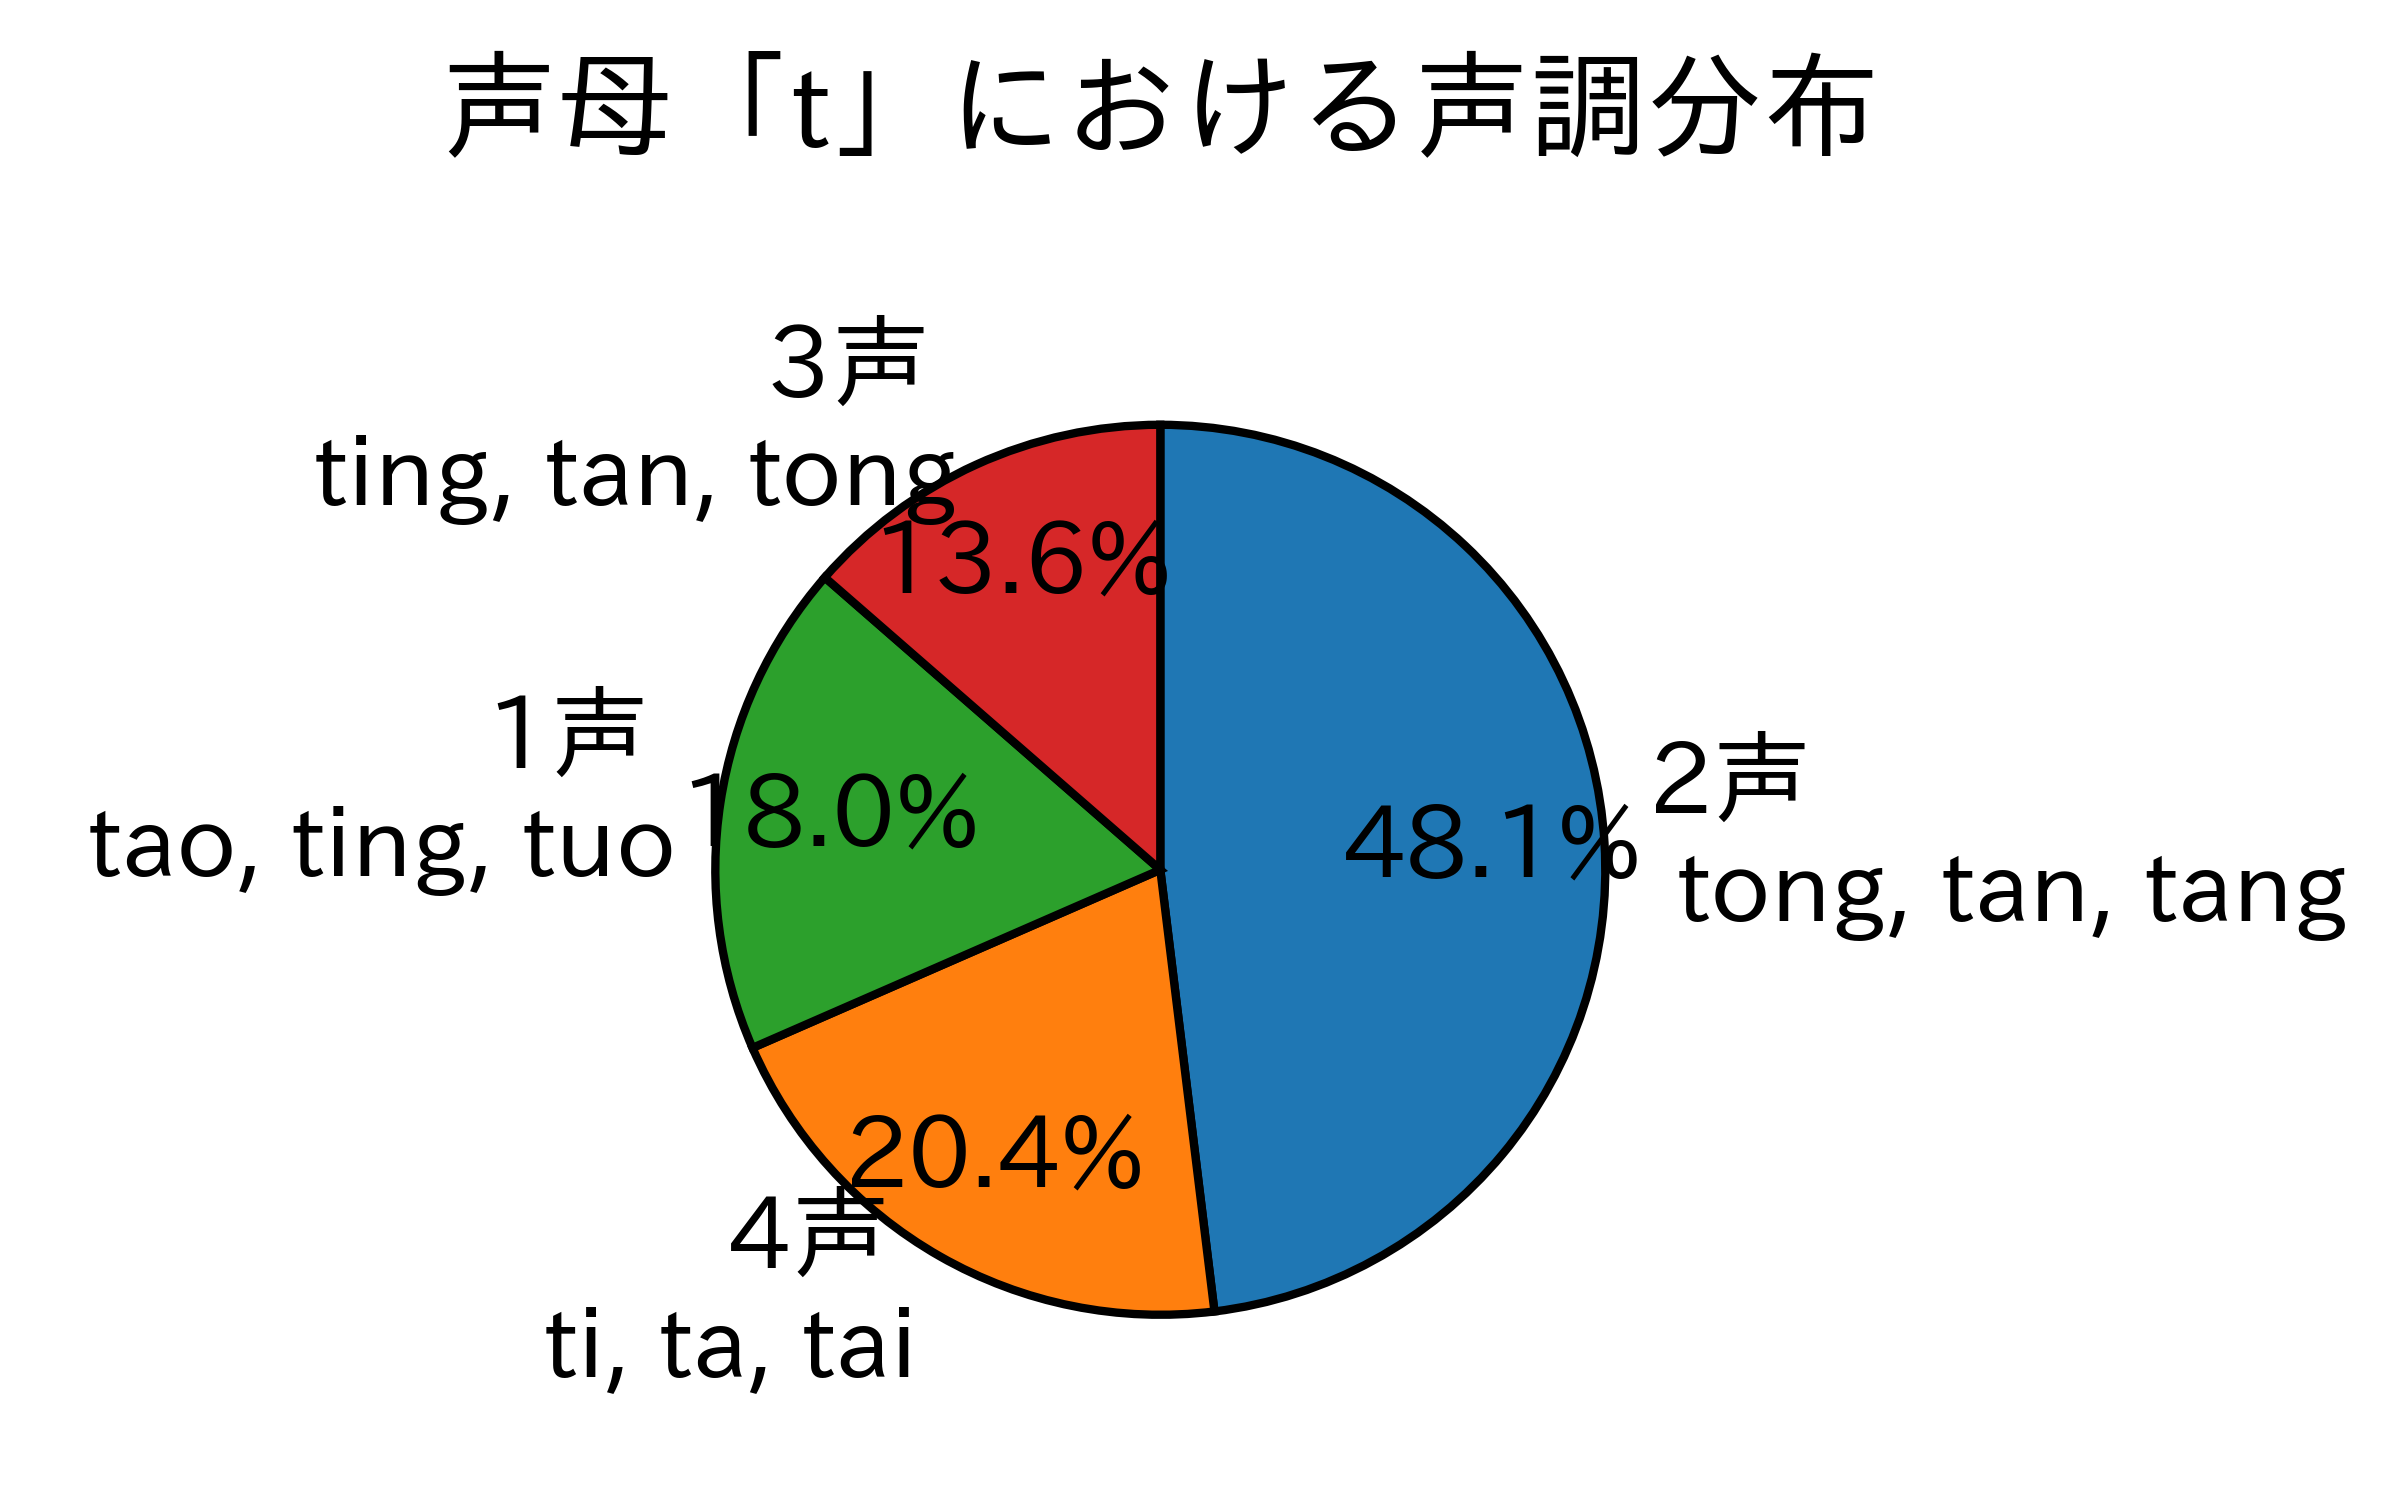

In [626]:
import matplotlib.pyplot as plt
import japanize_matplotlib
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})

tone_labels = {
    1: f"1声 \n {examples[1]}",
    2: f"2声 \n {examples[2]}",
    3: f"3声 \n {examples[3]}",
    4: f"4声 \n {examples[4]}",
    5: "軽声 }",
}

fig, ax = plt.subplots(figsize=(4, 4), dpi=600)

wedges, texts, autotexts = ax.pie(
    tone_counts.values,
    labels=[tone_labels[x] for x in tone_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={
        "linewidth": 1,
        "edgecolor": "black"
    }
)

ax.set_title(
    f"声母「{test_consonants}」における声調分布",
    pad=20
)

plt.tight_layout()
plt.show()

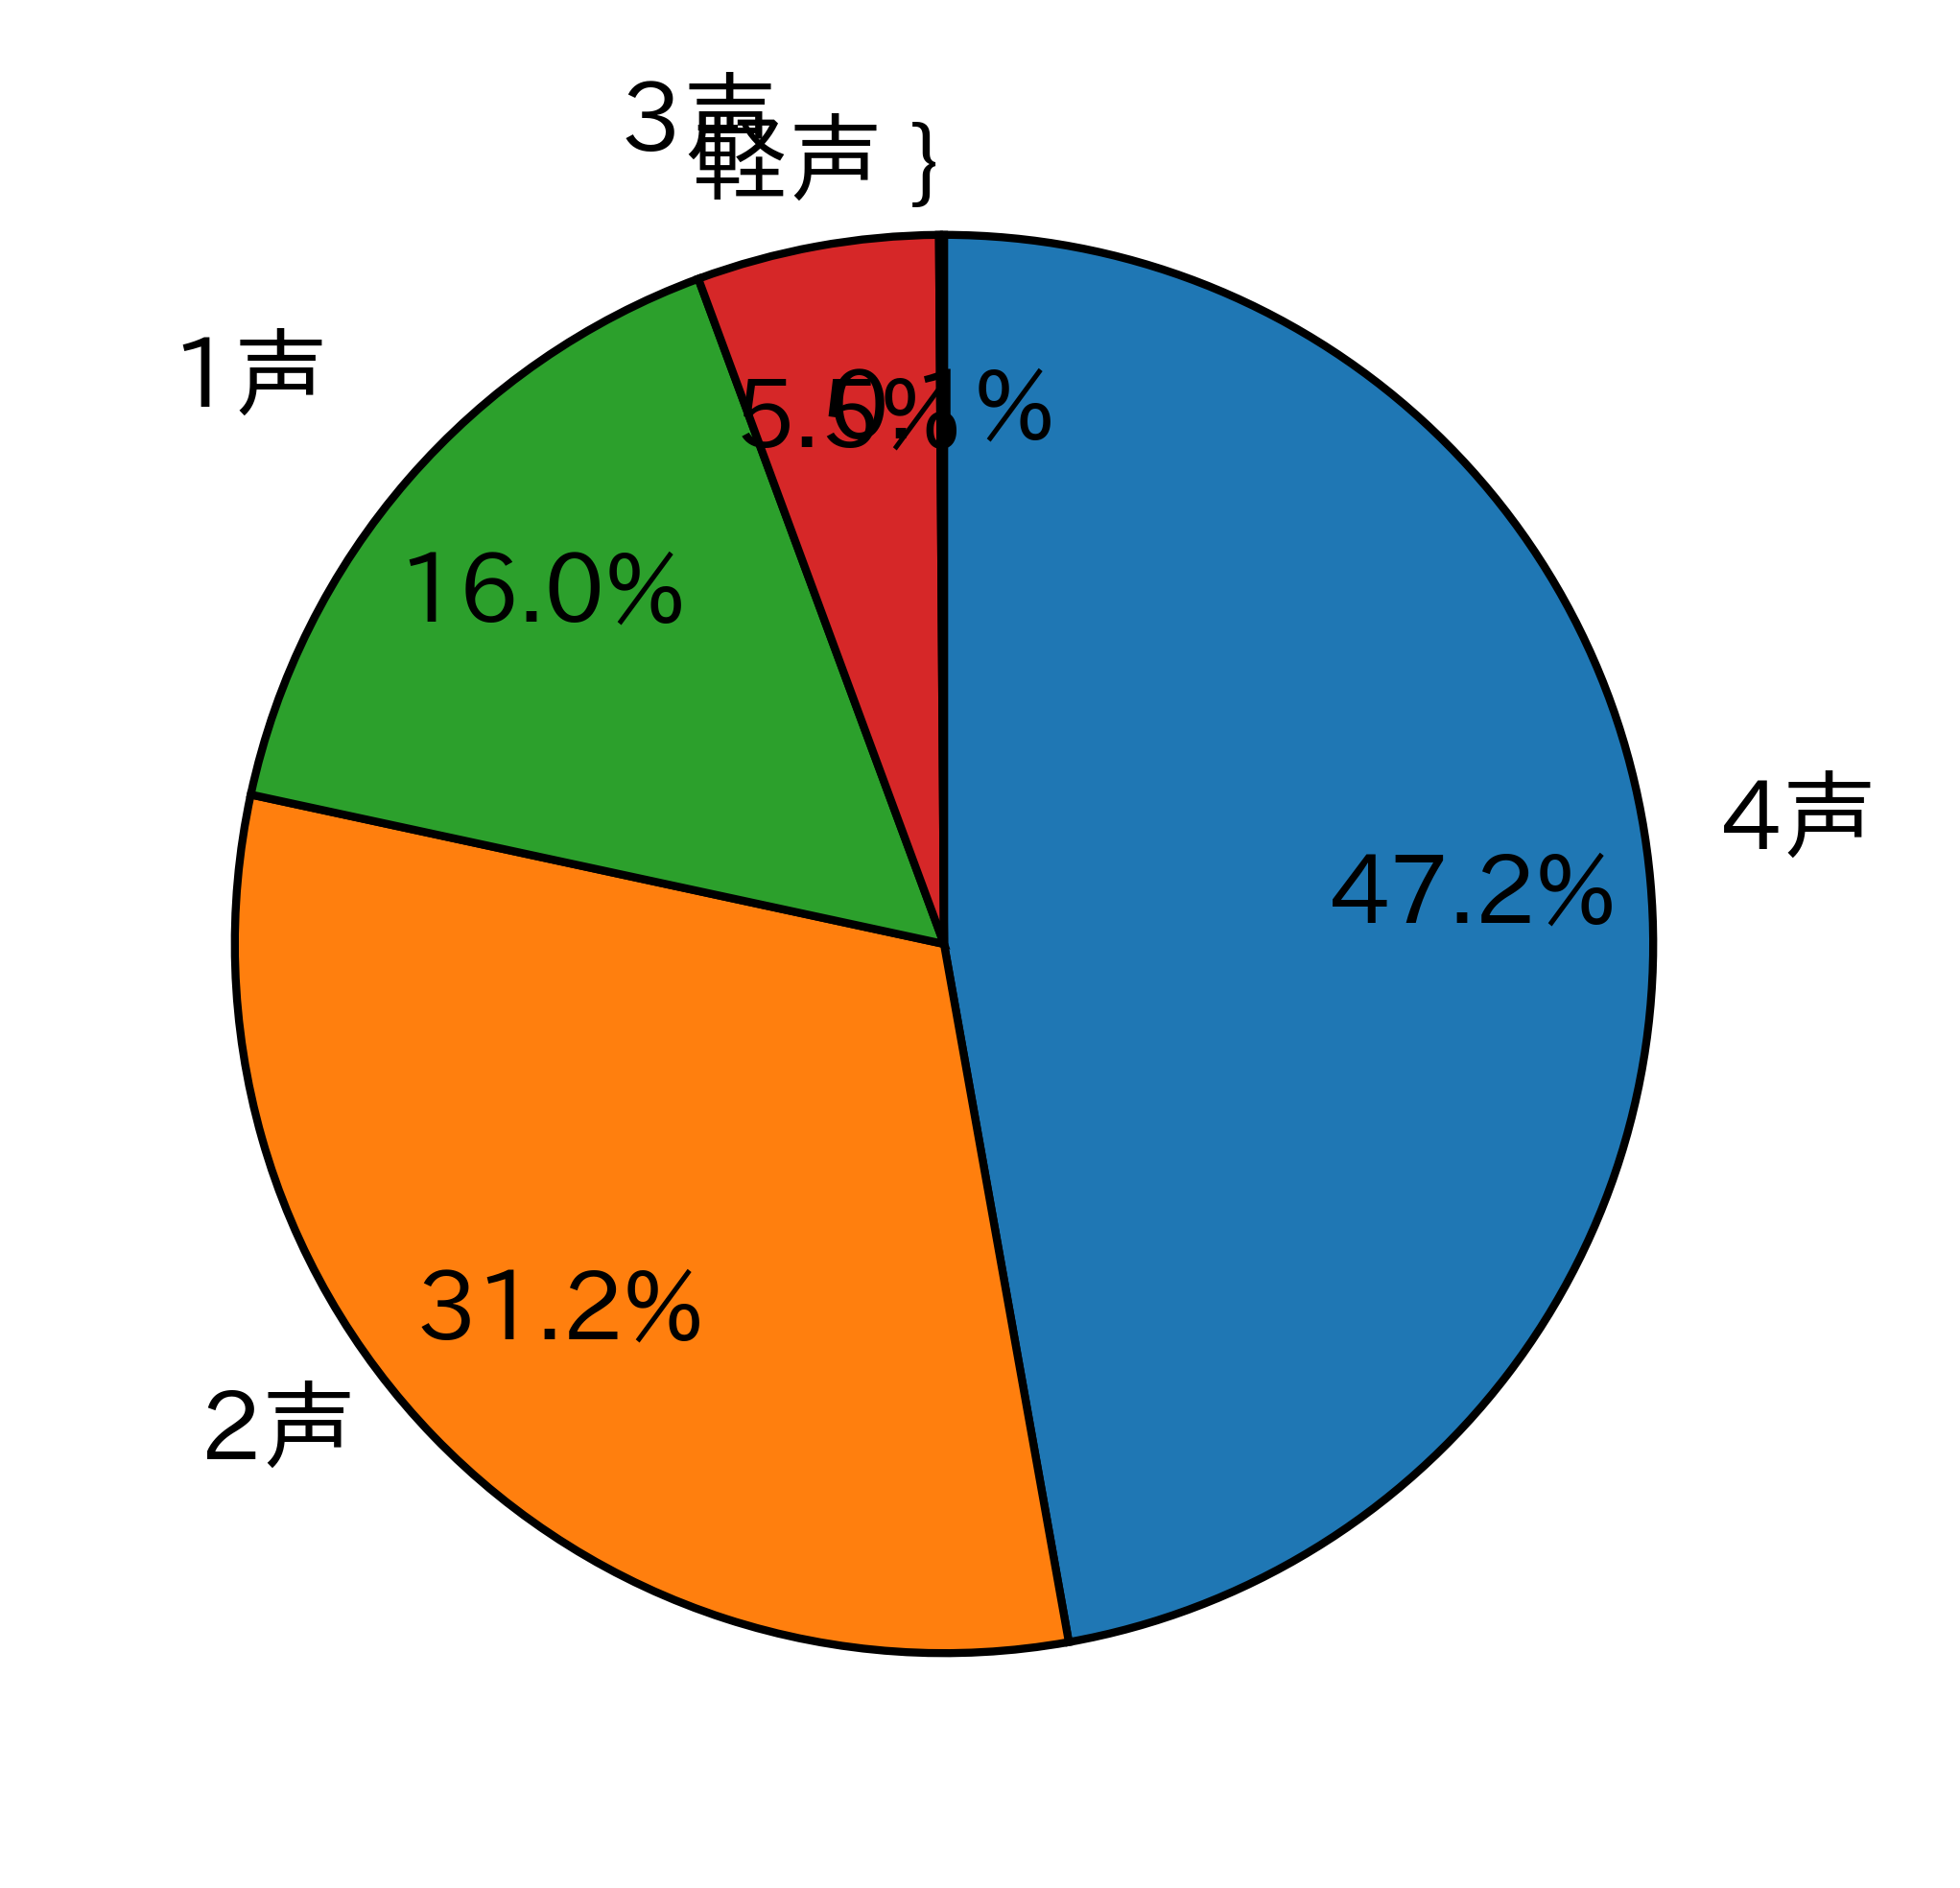

In [627]:
_df = df[df["middle_tone2"] == 4]

tone_counts = (
    _df["tone"]
    .value_counts()
)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})

tone_labels = {
    1: f"1声 \n ",
    2: f"2声 \n",
    3: f"3声 \n",
    4: f"4声 \n",
    5: "軽声 }",
}

fig, ax = plt.subplots(figsize=(4, 4), dpi=600)

wedges, texts, autotexts = ax.pie(
    tone_counts.values,
    labels=[tone_labels[x] for x in tone_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={
        "linewidth": 1,
        "edgecolor": "black"
    }
)

/tmp/ipykernel_1401/2264418726.py:103: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



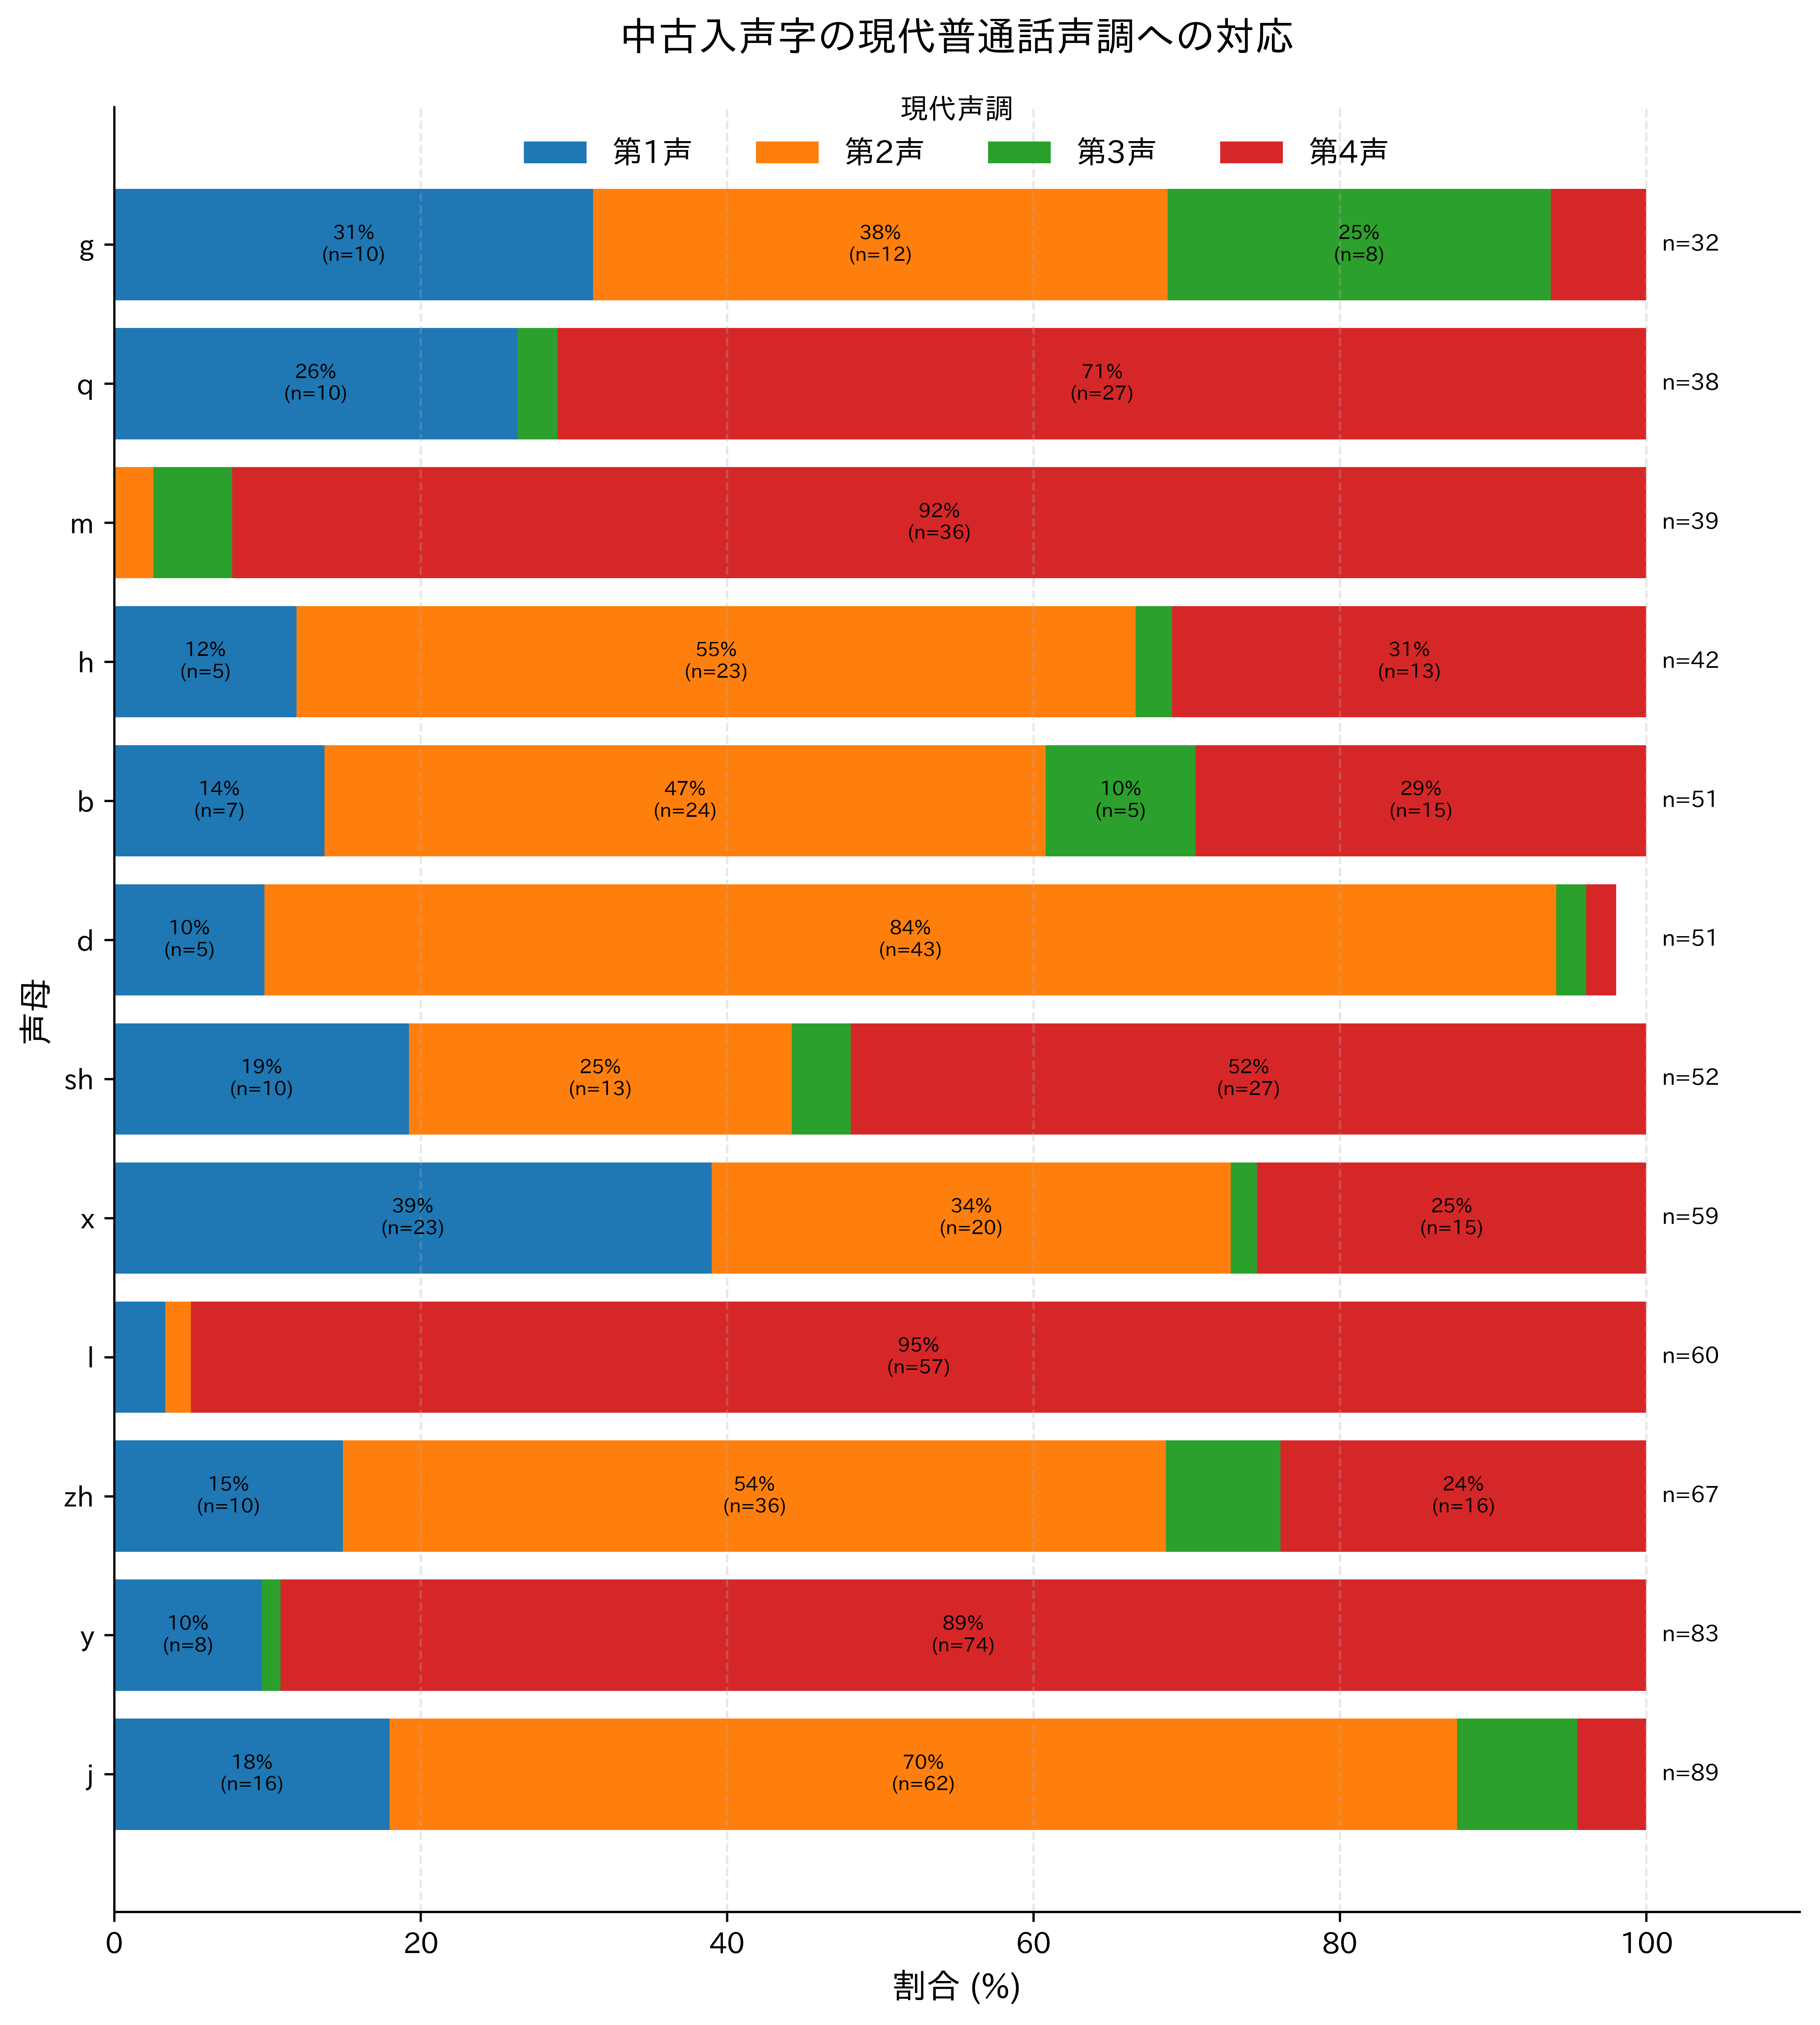

In [628]:
import matplotlib.pyplot as plt
import japanize_matplotlib

# ========================
# 中古入声のみ
# ========================

subset = df[df["middle_tone2"] == 4].copy()

# ========================
# 声母 × 現代声調
# ========================

ct = pd.crosstab(
    subset["consonants"],
    subset["tone"]
)

# 出現数が少なすぎる声母は除外
MIN_COUNT = 30

ct = ct.loc[
    ct.sum(axis=1) >= MIN_COUNT
]

# 総字数
totals = ct.sum(axis=1)

# 100%化
ct_pct = ct.div(
    totals,
    axis=0
) * 100

# 出現数順
order = totals.sort_values(
    ascending=False
).index

ct = ct.loc[order]
ct_pct = ct_pct.loc[order]
totals = totals.loc[order]

# 声調列を揃える
for tone in [1, 2, 3, 4]:

    if tone not in ct.columns:
        ct[tone] = 0
        ct_pct[tone] = 0

ct = ct[[1,2,3,4]]
ct_pct = ct_pct[[1,2,3,4]]

# ========================
# フォント
# ========================

plt.rcParams.update({
    "font.size": 10
})

# ========================
# 描画
# ========================

fig, ax = plt.subplots(
    figsize=(9, 10),
    dpi=600
)

left = np.zeros(len(ct_pct))

tone_labels = {
    1: "第1声",
    2: "第2声",
    3: "第3声",
    4: "第4声"
}

for tone in [1,2,3,4]:

    percentages = ct_pct[tone]
    counts = ct[tone]

    bars = ax.barh(
        ct_pct.index,
        percentages,
        left=left,
        label=tone_labels[tone]
    )

    # --------------------
    # バー内部に表示
    # --------------------

    for i, (pct, cnt) in enumerate(
        zip(percentages, counts)
    ):

        if pct >= 8:

            ax.text(
                left[i] + pct/2,
                i,
                f"{pct:.0f}%\n(n={cnt})",
                ha="center",
                va="center",
                fontsize=7
            )

    left += percentages

# ========================
# 総字数表示
# ========================

for i, total in enumerate(totals):

    ax.text(
        101,
        i,
        f"n={total}",
        va="center",
        fontsize=8
    )

# ========================
# 体裁
# ========================

ax.set_xlim(0, 110)

ax.set_xlabel("割合 (%)")
ax.set_ylabel("声母")

ax.set_title(
    "中古入声字の現代普通話声調への対応",
    fontsize=14,
    pad=20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="現代声調",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.95),
    loc="lower center"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

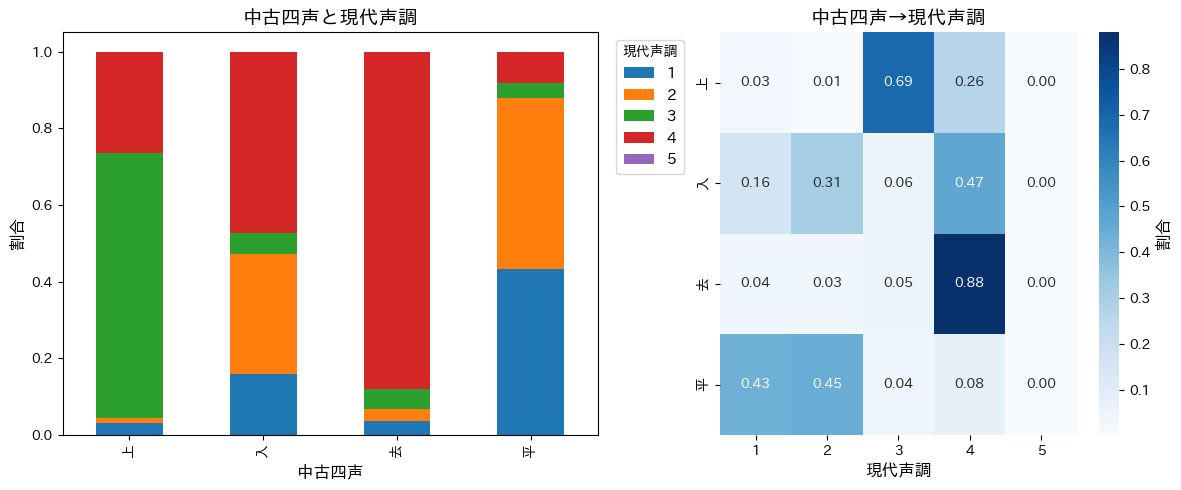

In [629]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# -----------------------
# クロス集計
# -----------------------
table = pd.crosstab(
    df["middle_tone"],
    df["tone"],
    normalize="index"
)

# -----------------------
# 描画
# -----------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    width_ratios=[1.2, 1]
)

# =======================
# 左：積み上げ棒グラフ
# =======================
table.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("中古四声と現代声調")
axes[0].set_xlabel("中古四声")
axes[0].set_ylabel("割合")
axes[0].legend(
    title="現代声調",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# =======================
# 右：ヒートマップ
# =======================
sns.heatmap(
    table,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[1],
    cbar_kws={"label": "割合"}
)

axes[1].set_title("中古四声→現代声調")
axes[1].set_xlabel("現代声調")
axes[1].set_ylabel("")

plt.tight_layout()

plt.savefig(
    "tone_analysis.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [630]:
df.to_csv("chinese_data.csv")

In [631]:
df[(df["middle_tone"] == "上")]

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone,middle_tone2
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,ou,False,zh,ang,4,澄陽三開,上,2
6,U+4E0A,上,上,上,ジョウ,상,shàng,571537,19.191638,j,ou,False,sh,ang,4,常陽三開,上,2
7,U+4E0B,下,下,下,カ,하,xià,359999,27.973638,k,a,False,x,ia,4,匣麻二開,上,2
9,U+4E11,丑,丑,丑,チュウ,축,chǒu,5499,94.720808,c,huu,False,ch,ou,3,徹尤三開,上,2
14,U+4E19,丙,丙,丙,ヘイ,병,bǐng,840,99.208698,h,ei,False,b,ing,3,幫庚三開,上,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5939,U+9F34,鼴,鼴,鼹,エン,언,yǎn,117,99.900294,,en,False,y,an,3,影元三開,上,2
5946,U+9F52,齒,齒,齿,シ,치,chǐ,4549,95.682896,s,hi,False,ch,i,3,昌之三開,上,2
5947,U+9F54,齔,齔,龀,シン,친,chèn,82,99.939367,s,hin,False,ch,en,4,初臻三開,上,2
5950,U+9F5F,齟,齟,龃,ソ,저,jǔ,135,99.880237,s,o,False,j,u,3,崇魚三開,上,2


In [632]:
df[(df["middle_tone"] == "平")&(df["tone"] == 1)]

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,vowel_jp,rusheng_jp,consonants,vowel,tone,middle_pronounce,middle_tone,middle_tone2
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,hou,False,d,ing,1,知耕二開,平,1
5,U+4E09,三,三,三,サン,삼,sān,141780,47.266322,s,an,False,s,an,1,心談一開,平,1
11,U+4E15,丕,丕,丕,ヒ,비,pī,506,99.498887,h,i,False,p,i,1,滂脂三開,平,1
13,U+4E18,丘,丘,丘,キュウ,구,qiū,3413,96.743860,k,yuu,False,q,iu,1,溪尤三開,平,1
16,U+4E1F,丟,丟,丢,チュウ,주,diū,8221,92.322664,c,huu,False,d,iu,1,端幽三開,平,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5944,U+9F4B,齋,齋,斋,サイ,재,zhāi,2422,97.755864,s,ai,False,zh,ai,1,莊皆二開,平,1
5945,U+9F4E,齎,齎,赍,シ,재,jī,111,99.906537,s,hi,False,j,i,1,精脂三開,平,1
5962,U+9F94,龔,龔,龚,キョウ,공,gōng,1019,99.042386,k,you,False,g,ong,1,見鍾三開,平,1
5963,U+9F95,龕,龕,龛,ガン,감,kān,295,99.728119,g,an,False,k,an,1,溪覃一開,平,1


### 子音清濁分類

In [635]:
import re

initials = [
    "幫","滂","並","明",
    "端","透","定","泥",
    "知","徹","澄","孃",
    "精","清","從","心","邪",
    "莊","初","崇","生","俟",
    "章","昌","常","書","船","日",
    "見","溪","群","疑",
    "影","曉","匣","云",
    "以","來"
]

def get_middle_initial(x):
    for ini in initials:
        if x.startswith(ini):
            return ini
    return None

df["middle_initial"] = df["middle_pronounce"].apply(get_middle_initial)

In [636]:
voicing_map = {}

for x in [
    "幫","端","知","精","莊","章",
    "見","影","曉","心","生","書"
]:
    voicing_map[x] = "全清"

for x in [
    "滂","透","徹","清","初","昌",
    "溪"
]:
    voicing_map[x] = "次清"

for x in [
    "並","定","澄","從","崇","常",
    "群","匣","邪","船","俟"
]:
    voicing_map[x] = "全濁"

for x in [
    "明","泥","孃","疑",
    "日","來","云","以"
]:
    voicing_map[x] = "次濁"

df["voice_class"] = (
    df["middle_initial"]
    .map(voicing_map)
)

In [637]:
def jp_voicing(cons):
    if cons in ["k","s","t","h"]:
        return "清"

    if cons in ["g","z","d","b"]:
        return "濁"

    if cons in ["p"]:
        return "半濁"

    if cons in ["m","n","r","w","y"]:
        return "鼻音・流音"

    return "その他"

df["jp_voicing"] = (
    df["consonant_jp"]
    .apply(jp_voicing)
)

In [638]:
retroflex = {
    "zh",
    "ch",
    "sh",
    "r"
}

df["retroflex"] = (
    df["consonants"]
    .isin(retroflex)
)
df

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,...,consonants,vowel,tone,middle_pronounce,middle_tone,middle_tone2,middle_initial,voice_class,jp_voicing,retroflex
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,...,d,ing,1,知耕二開,平,1,知,全清,その他,False
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171,s,...,q,i,1,清眞三開,入,4,清,次清,清,False
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882,m,...,w,an mo,4,明元三合,去,3,明,次濁,鼻音・流音,False
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,...,zh,ang,4,澄陽三開,上,2,澄,全濁,その他,True
5,U+4E09,三,三,三,サン,삼,sān,141780,47.266322,s,...,s,an,1,心談一開,平,1,心,全清,清,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,U+9F94,龔,龔,龚,キョウ,공,gōng,1019,99.042386,k,...,g,ong,1,見鍾三開,平,1,見,全清,清,False
5963,U+9F95,龕,龕,龛,ガン,감,kān,295,99.728119,g,...,k,an,1,溪覃一開,平,1,溪,次清,濁,False
5964,U+9F9C,龜,龜,龟,キ,구 귀 균,guī,2831,97.355973,k,...,g,ui,1,見脂三合,平,1,見,全清,清,False
5965,U+9FA0,龠,龠,龠,ヤク,약,yuè,5,99.996589,y,...,y,ue,4,以陽三開,入,4,以,次濁,鼻音・流音,False


In [639]:
import pandas as pd

def hangul_to_roman(text):
    """
    ハングル文字を公式のローマ字（Revised Romanization）表記に変換する関数
    """
    if pd.isna(text) or not isinstance(text, str):
        return text

    # ハングルの構成要素（初声・中声・終声）のローマ字対応表
    choseongs = ['g', 'kk', 'n', 'd', 'tt', 'r', 'm', 'b', 'pp', 's', 'ss', '', 'j', 'jj', 'ch', 'k', 't', 'p', 'h']
    jungseongs = ['a', 'ae', 'ya', 'yae', 'eo', 'e', 'yeo', 'ye', 'o', 'wa', 'wae', 'oe', 'yo', 'u', 'wo', 'we', 'wi', 'yu', 'eu', 'ui', 'i']
    jongseongs = ['', 'k', 'k', 'k', 'n', 'n', 'n', 't', 'l', 'k', 'm', 'l', 'l', 'l', 'p', 'l', 'm', 'p', 'p', 't', 't', 'ng', 't', 't', 'k', 't', 'p', 't']

    words = []
    # 複数の読みがスペースで区切られている場合を考慮
    for word in text.split():
        roman_chars = []
        for char in word:
            cp = ord(char)
            # ハングルの文字コード領域（U+AC00 〜 U+D7A3）であるか判定
            if 0xAC00 <= cp <= 0xD7A3:
                idx = cp - 0xAC00
                jong = idx % 28
                jung = (idx // 28) % 21
                cho = idx // 588

                # 各パーツを組み合わせてローマ字化
                r = choseongs[cho] + jungseongs[jung] + jongseongs[jong]
                roman_chars.append(r)
            else:
                # ハングル以外の文字はそのまま残す
                roman_chars.append(char)
        words.append("".join(roman_chars))

    return " ".join(words)

# --- お使いのデータフレームへの適用 ---
# 「韓国語の読み」列を変換して、新しい列「韓国語のローマ字」を作成します
# ※データフレームの変数名（df_kanjiなど）に合わせて変更してください
df['korean'] = df['韓国語の読み'].apply(hangul_to_roman)

# 結果の確認
df

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,...,vowel,tone,middle_pronounce,middle_tone,middle_tone2,middle_initial,voice_class,jp_voicing,retroflex,korean
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,...,ing,1,知耕二開,平,1,知,全清,その他,False,jeong
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171,s,...,i,1,清眞三開,入,4,清,次清,清,False,chil
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882,m,...,an mo,4,明元三合,去,3,明,次濁,鼻音・流音,False,man
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,...,ang,4,澄陽三開,上,2,澄,全濁,その他,True,jang
5,U+4E09,三,三,三,サン,삼,sān,141780,47.266322,s,...,an,1,心談一開,平,1,心,全清,清,False,sam
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,U+9F94,龔,龔,龚,キョウ,공,gōng,1019,99.042386,k,...,ong,1,見鍾三開,平,1,見,全清,清,False,gong
5963,U+9F95,龕,龕,龛,ガン,감,kān,295,99.728119,g,...,an,1,溪覃一開,平,1,溪,次清,濁,False,gam
5964,U+9F9C,龜,龜,龟,キ,구 귀 균,guī,2831,97.355973,k,...,ui,1,見脂三合,平,1,見,全清,清,False,gu gwi gyun
5965,U+9FA0,龠,龠,龠,ヤク,약,yuè,5,99.996589,y,...,ue,4,以陽三開,入,4,以,次濁,鼻音・流音,False,yak


In [640]:
import pandas as pd
import numpy as np

def map_jp_goon(c):
    """日本語子音の五音分類（伝統的な調音部位）"""
    if pd.isna(c):
        return '喉音'
    c = str(c).strip().lower()
    if c in ['k', 'g']: return '牙音'
    if c in ['s', 'z', 'j']: return '歯音'
    if c in ['t', 'd', 'c', 'ts']: return '舌音'
    if c == 'n': return '舌音'
    if c == 'r': return '流音'
    if c in ['h', 'f', 'b']: return '唇音'
    if c == 'm': return '唇音'
    if c == 'w': return '喉音'
    if c == 'y': return '喉音'
    return f'不明 ({c})'

def map_jp_seidaku(c):
    """日本語子音の清濁分類"""
    if pd.isna(c):
        return '次濁'
    c = str(c).strip().lower()
    if c in ['k', 's', 't', 'c', 'ts', 'h', 'f']: return '全清'
    if c in ['g', 'z', 'j', 'd', 'b']: return '全濁'
    if c in ['n', 'm', 'r', 'w', 'y']: return '次濁'
    return f'不明 ({c})'
def get_ko_initial_and_map(s):
    """韓国語のローマ字表記から初声を抽出し、五音・清濁にマッピング"""
    if pd.isna(s) or not isinstance(s, str) or len(s.strip()) == 0:
        return 'なし', 'なし', 'なし'

    # 大文字小文字のブレを防ぐため、すべて小文字に統一
    s_lower = s.strip().lower()

    # ローマ字（公式表記）の長い順にマッチング
    init = 'null'
    if s_lower.startswith('kk'): init = 'kk'
    elif s_lower.startswith('tt'): init = 'tt'
    elif s_lower.startswith('pp'): init = 'pp'
    elif s_lower.startswith('ss'): init = 'ss'
    elif s_lower.startswith('jj'): init = 'jj'
    elif s_lower.startswith('ch'): init = 'ch'
    elif s_lower.startswith('g'): init = 'g'
    elif s_lower.startswith('k'): init = 'k'
    elif s_lower.startswith('d'): init = 'd'
    elif s_lower.startswith('t'): init = 't'
    elif s_lower.startswith('r'): init = 'r'
    elif s_lower.startswith('n'): init = 'n'
    elif s_lower.startswith('b'): init = 'b'
    elif s_lower.startswith('p'): init = 'p'
    elif s_lower.startswith('m'): init = 'm'
    elif s_lower.startswith('j'): init = 'j'
    elif s_lower.startswith('s'): init = 's'
    elif s_lower.startswith('h'): init = 'h'

    # ハングル文字、五音、清濁のマッピング（すべて小文字キーに修正）
    mapping = {
        # 牙音
        'g': ('ㄱ', '牙音', '全清'),
        'k': ('ㅋ', '牙音', '次清'),
        'kk': ('ㄲ', '牙音', '全濁'),
        # 舌音・流音
        'd': ('ㄷ', '舌音', '全清'),
        't': ('ㅌ', '舌音', '次清'),
        'tt': ('ㄸ', '舌音', '全濁'),
        'n': ('ㄴ', '舌音', '次濁'),
        'r': ('ㄹ', '流音', '次濁'),
        # 唇音
        'b': ('ㅂ', '唇音', '全清'),
        'p': ('ㅍ', '唇音', '次清'),
        'pp': ('ㅃ', '唇音', '全濁'),
        # 歯音
        'j': ('ㅈ', '歯音', '全清'),
        'ch': ('ㅊ', '歯音', '次清'),
        'jj': ('ㅉ', '歯音', '全濁'),
        's': ('ㅅ', '歯音', '全清'),
        'ss': ('ㅆ', '歯音', '全濁'),
        # 喉音
        'h': ('ㅎ', '喉音', '次清'),
        'null': ('ㅇ', '喉音', '次濁')
    }

    # マッピングからハングル、五音、清濁を取得（登録がない場合はデフォルト値）
    return mapping.get(init, ('なし', 'なし', 'なし'))


# 2. 日本語の分類を適用
df['日本語_五音'] = df['consonant_jp'].apply(map_jp_goon)
df['日本語_清濁'] = df['consonant_jp'].apply(map_jp_seidaku)

# 3. 韓国語の分類を適用
ko_mapped = df['korean'].apply(get_ko_initial_and_map)
df['韓国語_子音'] = [x[0] for x in ko_mapped]
df['韓国語_五音'] = [x[1] for x in ko_mapped]
df['韓国語_清濁'] = [x[2] for x in ko_mapped]

# 4. 結果を新しいCSVファイルに保存
output_filename = 'chinese_data_classified.csv'
df.to_csv(output_filename, index=False)

print(f"分類が正常に追加され、'{output_filename}' として保存されました。")

分類が正常に追加され、'chinese_data_classified.csv' として保存されました。


In [641]:
df

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,...,middle_initial,voice_class,jp_voicing,retroflex,korean,日本語_五音,日本語_清濁,韓国語_子音,韓国語_五音,韓国語_清濁
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,...,知,全清,その他,False,jeong,舌音,全清,ㅈ,歯音,全清
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171,s,...,清,次清,清,False,chil,歯音,全清,ㅊ,歯音,次清
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882,m,...,明,次濁,鼻音・流音,False,man,唇音,次濁,なし,なし,なし
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,...,澄,全濁,その他,True,jang,歯音,全濁,ㅈ,歯音,全清
5,U+4E09,三,三,三,サン,삼,sān,141780,47.266322,s,...,心,全清,清,False,sam,歯音,全清,ㅅ,歯音,全清
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,U+9F94,龔,龔,龚,キョウ,공,gōng,1019,99.042386,k,...,見,全清,清,False,gong,牙音,全清,ㄱ,牙音,全清
5963,U+9F95,龕,龕,龛,ガン,감,kān,295,99.728119,g,...,溪,次清,濁,False,gam,牙音,全濁,ㄱ,牙音,全清
5964,U+9F9C,龜,龜,龟,キ,구 귀 균,guī,2831,97.355973,k,...,見,全清,清,False,gu gwi gyun,牙音,全清,ㄱ,牙音,全清
5965,U+9FA0,龠,龠,龠,ヤク,약,yuè,5,99.996589,y,...,以,次濁,鼻音・流音,False,yak,喉音,次濁,ㅇ,喉音,次濁


In [643]:
import pandas as pd
import numpy as np

# --- 既存の日本語・韓国語の関数（省略） ---

def map_zh_modern_goon(c):
    """
    現代中国語（ピンイン・consonants列）の五音分類
    """
    if pd.isna(c) or not isinstance(c, str) or len(c) == 0:
        return '喉音' # ゼロ声母（子音なし）

    c = str(c).strip().lower()

    # 現代ピンインの子音（声母）の調音部位による分類
    if c in ['b', 'p', 'm', 'f']: return '唇音'
    if c in ['d', 't', 'n', 'l']: return '舌音'
    if c in ['g', 'k', 'h']: return '牙音'
    if c in ['z', 'c', 's', 'zh', 'ch', 'sh', 'r', 'j', 'q', 'x']: return '歯音'
    if c in ['w', 'y']: return '喉音' # 半母音

    return f'不明 ({c})'


def map_zh_modern_seidaku(c):
    """
    現代中国語（ピンイン・consonants列）の清濁分類
    現代語の「無気音＝全清」「有気音/摩擦清音＝次清」「有声音＝次濁」に対応させます
    """
    if pd.isna(c) or not isinstance(c, str) or len(c) == 0:
        return '次濁' # ゼロ声母は次濁扱い

    c = str(c).strip().lower()

    # 全清：無気・清栓塞音/塞擦音
    if c in ['b', 'd', 'g', 'z', 'zh', 'j']:
        return '全清'

    # 次清：有気音、および清摩擦音（f, s, sh, x, h）
    if c in ['p', 't', 'k', 'c', 'ch', 'q', 'f', 's', 'sh', 'x', 'h']:
        return '次清'

    # 次濁：有声音（鼻音・流音・摩擦有声音）
    if c in ['m', 'n', 'l', 'r', 'w', 'y']:
        return '次濁'

    return f'不明 ({c})'




# 2. 日本語の分類を適用
df['日本語_五音'] = df['consonant_jp'].apply(map_jp_goon)
df['日本語_清濁'] = df['consonant_jp'].apply(map_jp_seidaku)

# 3. 韓国語の分類を適用
ko_mapped = df['korean'].apply(get_ko_initial_and_map)
df['韓国語_子音'] = [x[0] for x in ko_mapped]
df['韓国語_五音'] = [x[1] for x in ko_mapped]
df['韓国語_清濁'] = [x[2] for x in ko_mapped]

# 4. 中国語（現代語・ピンイン基準）の分類を適用 【修正箇所】
df['中国語_五音'] = df['consonants'].apply(map_zh_modern_goon)
df['中国語_清濁'] = df['consonants'].apply(map_zh_modern_seidaku)

# 5. 結果を新しいCSVファイルに保存
output_filename = 'chinese_data_classified.csv'
df.to_csv(output_filename, index=False)

print(f"現代中国語の基準で分類が正常に追加され、'{output_filename}' として保存されました。")

現代中国語の基準で分類が正常に追加され、'chinese_data_classified.csv' として保存されました。


In [644]:
# One-Hot Encodingしたい列
cols = [
    "consonants",     # 中国語子音
    "vowel",          # 中国語母音
    "consonant_jp",   # 日本語子音
    "vowel_jp"        # 日本語母音
]

df_onehot = pd.get_dummies(
    df,
    columns=cols,
    prefix=cols,
    dtype=int
)

print(df_onehot.shape)
print(df_onehot.head())

(5594, 201)
  Unicode 漢字 繁体字 汉字 日本語の読み 韓国語の読み    ピンイン      频率    累计频率(%)  rusheng_jp  ...  \
1  U+4E01  丁   丁  丁    チョウ      정    dīng   12190  89.141422       False  ...   
2  U+4E03  七   七  七     シチ      칠      qī   35499  73.707171        True  ...   
3  U+4E07  万   万  万     マン      만  wàn mò   53972  66.690882       False  ...   
4  U+4E08  丈   丈  丈    ジョウ      장   zhàng   16371  86.112300       False  ...   
5  U+4E09  三   三  三     サン      삼     sān  141780  47.266322       False  ...   

   vowel_jp_ui vowel_jp_uku vowel_jp_un  vowel_jp_utsu vowel_jp_uu  \
1            0            0           0              0           0   
2            0            0           0              0           0   
3            0            0           0              0           0   
4            0            0           0              0           0   
5            0            0           0              0           0   

  vowel_jp_yaku vowel_jp_yo  vowel_jp_yoku vowel_jp_you vowel_jp_yuu  
1        

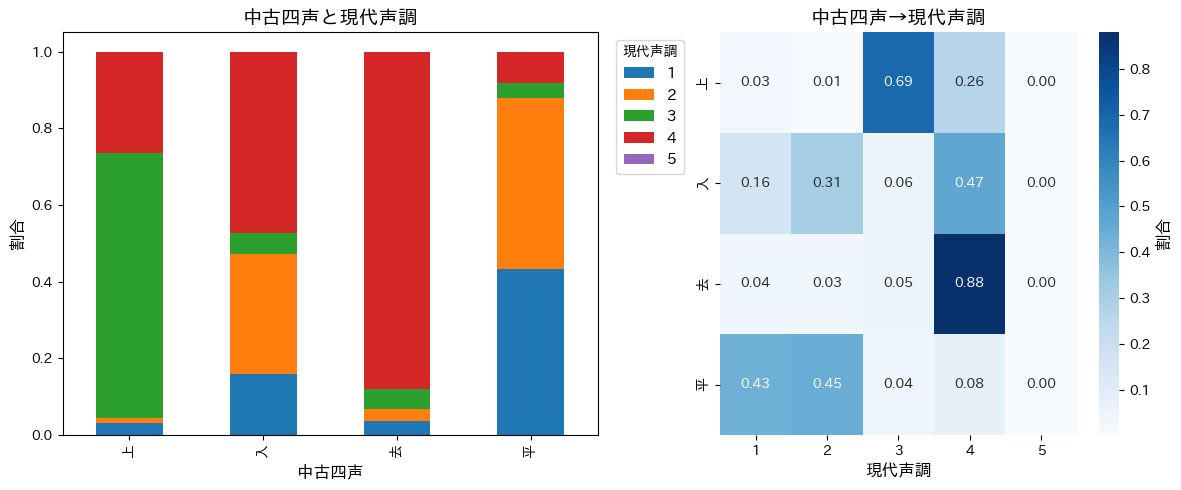

In [645]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# -----------------------
# クロス集計
# -----------------------
table = pd.crosstab(
    df["middle_tone"],
    df["tone"],
    normalize="index"
)

# -----------------------
# 描画
# -----------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    width_ratios=[1.2, 1]
)

# =======================
# 左：積み上げ棒グラフ
# =======================
table.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("中古四声と現代声調")
axes[0].set_xlabel("中古四声")
axes[0].set_ylabel("割合")
axes[0].legend(
    title="現代声調",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# =======================
# 右：ヒートマップ
# =======================
sns.heatmap(
    table,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[1],
    cbar_kws={"label": "割合"}
)

axes[1].set_title("中古四声→現代声調")
axes[1].set_xlabel("現代声調")
axes[1].set_ylabel("")

plt.tight_layout()

plt.savefig(
    "tone_analysis.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [646]:
df

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,...,jp_voicing,retroflex,korean,日本語_五音,日本語_清濁,韓国語_子音,韓国語_五音,韓国語_清濁,中国語_五音,中国語_清濁
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,...,その他,False,jeong,舌音,全清,ㅈ,歯音,全清,舌音,全清
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171,s,...,清,False,chil,歯音,全清,ㅊ,歯音,次清,歯音,次清
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882,m,...,鼻音・流音,False,man,唇音,次濁,なし,なし,なし,喉音,次濁
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,...,その他,True,jang,歯音,全濁,ㅈ,歯音,全清,歯音,全清
5,U+4E09,三,三,三,サン,삼,sān,141780,47.266322,s,...,清,False,sam,歯音,全清,ㅅ,歯音,全清,歯音,次清
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,U+9F94,龔,龔,龚,キョウ,공,gōng,1019,99.042386,k,...,清,False,gong,牙音,全清,ㄱ,牙音,全清,牙音,全清
5963,U+9F95,龕,龕,龛,ガン,감,kān,295,99.728119,g,...,濁,False,gam,牙音,全濁,ㄱ,牙音,全清,牙音,次清
5964,U+9F9C,龜,龜,龟,キ,구 귀 균,guī,2831,97.355973,k,...,清,False,gu gwi gyun,牙音,全清,ㄱ,牙音,全清,牙音,全清
5965,U+9FA0,龠,龠,龠,ヤク,약,yuè,5,99.996589,y,...,鼻音・流音,False,yak,喉音,次濁,ㅇ,喉音,次濁,喉音,次濁


In [647]:
# 1. 文字列を数字にマッピングする辞書を作成
goon_map = {'唇音': 1, '舌音': 2, '牙音': 3, '歯音': 4, '喉音': 5, '流音': 6, 'なし': 0}

# 2. 新しい一時的なデータフレームに数字に変換した値を代入
df_num = pd.DataFrame()
df_num['日本語_五音_num'] = df['日本語_五音'].map(goon_map)
df_num['韓国語_五音_num'] = df['韓国語_五音'].map(goon_map)
df_num['中国語_五音_num'] = df['中国語_五音'].map(goon_map)


# 3. これなら相関（.corr()）が計算できます！
corr = df_num[["日本語_五音_num", "韓国語_五音_num","中国語_五音_num",]].corr()
print(corr)



# 1. 文字列を数字にマッピングする辞書を作成
goon_map = {'全濁': 1, '次濁': 2, '全清': 3, '次清': 4}

# 2. 新しい一時的なデータフレームに数字に変換した値を代入
df_num = pd.DataFrame()
df_num['日本語_清濁_num'] = df['日本語_清濁'].map(goon_map)
df_num['韓国語_清濁_num'] = df['韓国語_清濁'].map(goon_map)
df_num['中国語_清濁_num'] = df['中国語_清濁'].map(goon_map)


# 3. これなら相関（.corr()）が計算できます！
corr = df_num[["日本語_清濁_num", "韓国語_清濁_num","中国語_清濁_num",]].corr()
print(corr)


            日本語_五音_num  韓国語_五音_num  中国語_五音_num
日本語_五音_num    1.000000    0.758193    0.481447
韓国語_五音_num    0.758193    1.000000    0.617192
中国語_五音_num    0.481447    0.617192    1.000000
            日本語_清濁_num  韓国語_清濁_num  中国語_清濁_num
日本語_清濁_num    1.000000    0.423272    0.484547
韓国語_清濁_num    0.423272    1.000000    0.690981
中国語_清濁_num    0.484547    0.690981    1.000000


In [648]:
df[
    (df["日本語_清濁"] =="全濁")
    &(df["中国語_清濁"] == "次清")
][["漢字","tone", "middle_tone"]]


,漢字,tone,middle_tone
6,上,4,上
15,丞,2,平
30,乏,2,入
32,乘,2,平
42,事,4,去
...,...,...,...
5892,麝,4,去
5917,黥,2,平
5934,鼙,2,平
5953,齦,3,平


In [651]:
seidaku1 = ["全清", "次清", "次濁", "全濁"]
seidaku2 = seidaku1
tone = [1, 2, 3, 4]

print("==== 日本語・中国語の清濁・声調別 集計結果 ====")

for i in seidaku1:
    # 該当する日本語の清濁があるか確認
    _dum_jp = df[df["日本語_清濁"] == i]
    if _dum_jp.empty:
        continue

    print(f"\n■ 日本語: {i}")

    for j in seidaku2:
        _dum = _dum_jp[_dum_jp["中国語_清濁"] == j].sort_values(by="频率", ascending=False)
        if _dum.empty:
            continue

        print(f"  └─ 中国語: {j}")

        for k in tone:
            _dumi = _dum[_dum["tone"] == k]
            if len(_dumi) == 0:
                continue  # 0文字の組み合わせは表示しない

            # 出現頻度順を維持したまま、重複のないユニークな漢字を5つ抽出
            top_chars = []
            for char in _dumi["漢字"]:
                if char not in top_chars:
                    top_chars.append(char)
                if len(top_chars) == 5:
                    break
            examples = ", ".join(top_chars)

            # 綺麗にインデントして出力
            print(f"      ├─ {k}声: {len(_dumi):3d}字  (例: {examples})")

==== 日本語・中国語の清濁・声調別 集計結果 ====

■ 日本語: 全清
  └─ 中国語: 全清
      ├─ 1声: 500字  (例: 中, 之, 都, 隻, 家)
      ├─ 2声: 186字  (例: 得, 國, 白, 覺, 直)
      ├─ 3声: 304字  (例: 子, 只, 把, 長, 點)
      ├─ 4声: 504字  (例: 不, 這, 個, 到, 地)
  └─ 中国語: 次清
      ├─ 1声: 597字  (例: 他, 說, 出, 生, 天)
      ├─ 2声: 569字  (例: 還, 頭, 回, 成, 行)
      ├─ 3声: 266字  (例: 可, 小, 好, 起, 想)
      ├─ 4声: 601字  (例: 下, 去, 看, 后, 會)
  └─ 中国語: 次濁
      ├─ 1声:   7字  (例: 危, 巫, 誣, 渦, 洼)
      ├─ 2声:  17字  (例: 完, 宁, 昂, 萌, 螢)
      ├─ 3声:  15字  (例: 鳥, 咬, 吻, 染, 紐)
      ├─ 4声:  37字  (例: 樣, 秘, 叶, 率, 硬)

■ 日本語: 次濁
  └─ 中国語: 全清
      ├─ 1声:   1字  (例: 粘)
      ├─ 4声:   1字  (例: 窶)
  └─ 中国語: 次清
      ├─ 1声:   3字  (例: 輸, 鑲, 砢)
      ├─ 2声:   6字  (例: 和, 雄, 熊, 淮, 釐)
      ├─ 4声:   5字  (例: 話, 或, 惑, 耗, 賄)
  └─ 中国語: 次濁
      ├─ 1声:  46字  (例: 幺, 應, 拉, 約, 勒)
      ├─ 2声: 295字  (例: 來, 能, 年, 無, 无)
      ├─ 3声: 110字  (例: 瞭, 有, 也, 裏, 里)
      ├─ 4声: 237字  (例: 那, 要, 面, 麵, 又)

■ 日本語: 全濁
  └─ 中国語: 全清
      ├─ 1声:  30字  (例: 軍, 該, 擊, 剛, 激)
      ├─ 2声:  25字  (例: 別, 絕, 獨, 族, 毒)
  

In [653]:
import pandas as pd
import plotly.express as px

def plot_sunburst(
    df,
    path,
    value_col="频率",
    title=None
):
    """
    path:
        ["middle_tone"]
        ["middle_tone","日本語_五音"]
        ["middle_tone","日本語_五音","日本語_清濁"]
        ...
    """

    df_plot = (
        df.groupby(path, as_index=False)[value_col]
        .sum()
    )

    fig = px.sunburst(
        df_plot,
        path=path,
        values=value_col,
        color=path[0],
    )

    fig.update_layout(
        title=title or "Sunburst",
        font=dict(size=16),
        margin=dict(t=80, l=20, r=20, b=20)
    )

    fig.show()

In [654]:
plot_sunburst(
    df[(df["tone"] == 1)|(df["tone"] == 2)|(df["tone"] == 3)|(df["tone"] == 4)],
    [
        # "middle_tone",
        "tone",
        "日本語_清濁",
        "日本語_五音"
    ]
)

In [655]:
plot_sunburst(
    df[(df["tone"] == 1)|(df["tone"] == 2)|(df["tone"] == 3)|(df["tone"] == 4)],
    [
        # "middle_tone",
        "tone",
        # "日本語_五音",
        "韓国語_清濁"
    ]
)

In [656]:
import pandas as pd
import plotly.express as px

def plot_sunburst(
    df,
    path,
    value_col="频率",
    title=None,
    example_n=10
):

    # --------------------
    # 集計
    # --------------------

    agg = (
        df.groupby(path)
          .agg(
              頻度=(value_col,"sum"),
              漢字数=("漢字","count")
          )
          .reset_index()
    )

    # --------------------
    # 代表漢字
    # --------------------

    examples = (
        df.groupby(path)
          .apply(
              lambda x:
              "、".join(
                  f"{h}({p})"
                  for h,p in zip(
                      x["漢字"].head(example_n),
                      x["ピンイン"].head(example_n)
                  )
              )
          )
          .reset_index(name="代表例")
    )

    agg = agg.merge(
        examples,
        on=path,
        how="left"
    )

    # --------------------
    # Sunburst
    # --------------------

    fig = px.sunburst(
        agg,
        path=path,
        values="頻度",
        color=path[0],
        custom_data=[
            "漢字数",
            "代表例"
        ]
    )

    # --------------------
    # Hover
    # --------------------

    fig.update_traces(
        hovertemplate=
        "<b>%{label}</b><br>"
        "頻度: %{value:,}<br>"
        "漢字数: %{customdata[0]:,}<br>"
        "代表例:<br>%{customdata[1]}"
        "<extra></extra>"
    )

    # --------------------
    # 説明
    # --------------------

    note = """
<b>音韻分類</b><br><br>

<b>清濁</b><br>
全清：無気清音<br>
次清：有気清音<br>
全濁：有声阻害音<br>
次濁：鼻音・流音<br><br>

<b>五音</b><br>
唇音：p,b,m,f<br>
舌音：t,d,n,l<br>
歯音：s,z,c,j系<br>
牙音：k,g系<br>
喉音：h,y,w,零声母
"""

    fig.add_annotation(
        x=1.15,
        y=0.5,
        xref="paper",
        yref="paper",
        align="left",
        showarrow=False,
        text=note,
        bordercolor="gray",
        borderwidth=1,
        bgcolor="white",
        font=dict(size=12)
    )

    fig.update_layout(
        title=title or "Sunburst",
        font=dict(size=15),
        margin=dict(
            t=80,
            l=40,
            r=700,
            b=20
        )
    )

    fig.show()

In [657]:
plot_sunburst(
    df[(df["tone"] == 1)|(df["tone"] == 2)|(df["tone"] == 3)|(df["tone"] == 4)],
    [
        # "middle_tone",
        "tone",
        # "日本語_五音",
        "日本語_清濁"
    ]
)

/tmp/ipykernel_1401/2814503223.py:31: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [658]:
plot_sunburst(
    df[(df["tone"] == 1)|(df["tone"] == 2)|(df["tone"] == 3)|(df["tone"] == 4)],
    [
        "middle_tone",
        "tone",
        # "日本語_五音",
        "日本語_清濁"
    ]
)

/tmp/ipykernel_1401/2814503223.py:31: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [660]:
goon_order = {
    "唇音": ["b", "p", "m", "f"],
    "舌尖音": ["d", "t", "n", "l", "z", "c", "s"],
    "舌面音": ["j", "q", "x"],
    "舌根音": ["g", "k", "h"],
    "巻舌音": ["zh", "ch", "sh", "r"]
}

In [661]:
ordered_consonants = []
group_index = {}

start = 0

for g, cons in goon_order.items():
    ordered_consonants.extend(cons)
    for c in cons:
        group_index[c] = g

In [662]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df2 = df.dropna(subset=["vowel", "consonants", "middle_tone"]).copy()

tones = ["平", "上", "去", "入"]

In [663]:
group_colors = {
    "唇音": "#4C78A8",
    "舌尖音": "#F58518",
    "舌面音": "#E45756",
    "牙音": "#72B7B2",
    "舌根音": "#54A24B",
    "巻舌音":  "#E45756"
}

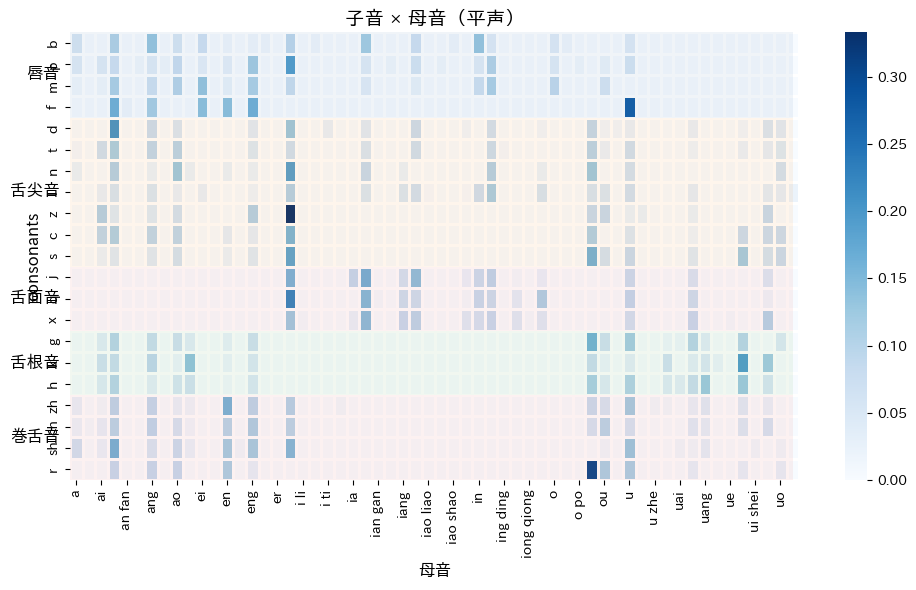

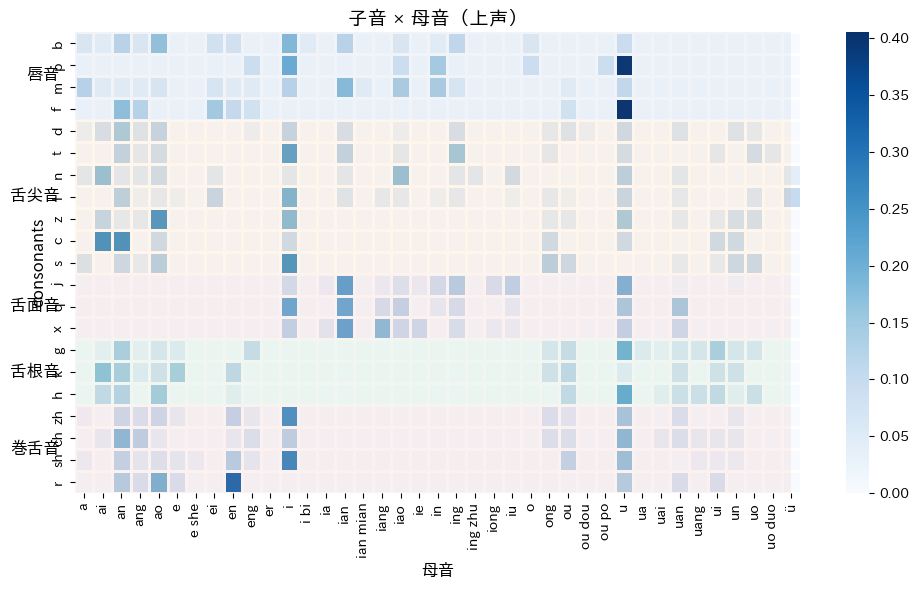

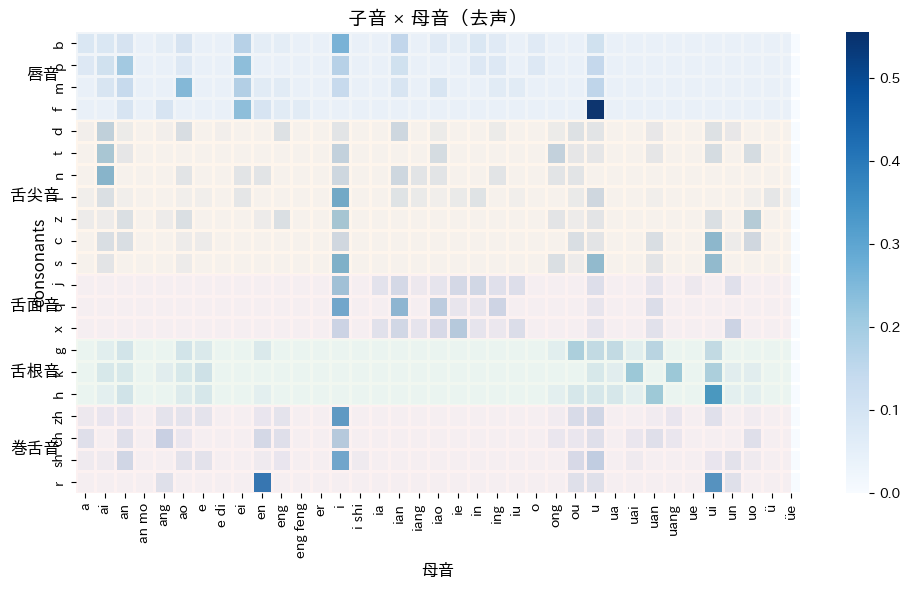

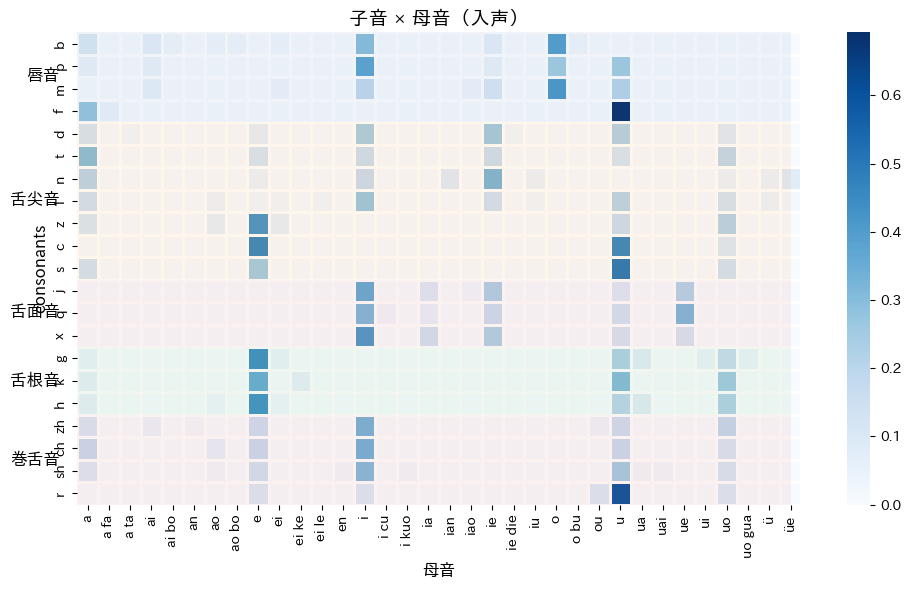

In [664]:
for tone in tones:

    sub = df2[df2["middle_tone"] == tone]

    ct = pd.crosstab(sub["consonants"], sub["vowel"])
    ct = ct.reindex(ordered_consonants).fillna(0)

    ct_ratio = ct.div(ct.sum(axis=1), axis=0).fillna(0)

    # -------------------------
    # 描画
    # -------------------------
    plt.figure(figsize=(10, 6))

    ax = sns.heatmap(
        ct_ratio,
        cmap="Blues",
        linewidths=0.8,      # ← 枠線
        linecolor="white",   # ← 枠線色
        cbar=True
    )

    # -------------------------
    # グループごとに色帯を追加
    # -------------------------
    y = 0

    for g, cons in goon_order.items():

        ax.add_patch(
            plt.Rectangle(
                (-0.5, y),
                ct_ratio.shape[1],
                len(cons),
                fill=True,
                color=group_colors[g],
                alpha=0.08,
                lw=0
            )
        )

        # ラベル
        ax.text(
            -0.8,
            y + len(cons)/2,
            g,
            va="center",
            ha="right",
            fontsize=12,
            fontweight="bold"
        )

        y += len(cons)

    plt.title(f"子音 × 母音（{tone}声）")
    plt.xlabel("母音")
    # plt.ylabel("子音（五音分類）")

    plt.tight_layout()
    plt.show()

In [665]:
vowels = df["vowel"].dropna()

In [666]:
df[df["漢字"] == "東"]

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,...,jp_voicing,retroflex,korean,日本語_五音,日本語_清濁,韓国語_子音,韓国語_五音,韓国語_清濁,中国語_五音,中国語_清濁
2049,U+6771,東,東,东,トウ,동,dōng,94140,54.745063,t,...,清,False,dong,舌音,全清,ㄷ,舌音,全清,舌音,全清


In [668]:
df

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,...,jp_voicing,retroflex,korean,日本語_五音,日本語_清濁,韓国語_子音,韓国語_五音,韓国語_清濁,中国語_五音,中国語_清濁
1,U+4E01,丁,丁,丁,チョウ,정,dīng,12190,89.141422,c,...,その他,False,jeong,舌音,全清,ㅈ,歯音,全清,舌音,全清
2,U+4E03,七,七,七,シチ,칠,qī,35499,73.707171,s,...,清,False,chil,歯音,全清,ㅊ,歯音,次清,歯音,次清
3,U+4E07,万,万,万,マン,만,wàn mò,53972,66.690882,m,...,鼻音・流音,False,man,唇音,次濁,なし,なし,なし,喉音,次濁
4,U+4E08,丈,丈,丈,ジョウ,장,zhàng,16371,86.112300,j,...,その他,True,jang,歯音,全濁,ㅈ,歯音,全清,歯音,全清
5,U+4E09,三,三,三,サン,삼,sān,141780,47.266322,s,...,清,False,sam,歯音,全清,ㅅ,歯音,全清,歯音,次清
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,U+9F94,龔,龔,龚,キョウ,공,gōng,1019,99.042386,k,...,清,False,gong,牙音,全清,ㄱ,牙音,全清,牙音,全清
5963,U+9F95,龕,龕,龛,ガン,감,kān,295,99.728119,g,...,濁,False,gam,牙音,全濁,ㄱ,牙音,全清,牙音,次清
5964,U+9F9C,龜,龜,龟,キ,구 귀 균,guī,2831,97.355973,k,...,清,False,gu gwi gyun,牙音,全清,ㄱ,牙音,全清,牙音,全清
5965,U+9FA0,龠,龠,龠,ヤク,약,yuè,5,99.996589,y,...,鼻音・流音,False,yak,喉音,次濁,ㅇ,喉音,次濁,喉音,次濁


In [669]:
df[df["漢字"]=="東"]

,Unicode,漢字,繁体字,汉字,日本語の読み,韓国語の読み,ピンイン,频率,累计频率(%),consonant_jp,...,jp_voicing,retroflex,korean,日本語_五音,日本語_清濁,韓国語_子音,韓国語_五音,韓国語_清濁,中国語_五音,中国語_清濁
2049,U+6771,東,東,东,トウ,동,dōng,94140,54.745063,t,...,清,False,dong,舌音,全清,ㄷ,舌音,全清,舌音,全清


In [670]:
df.columns

Index(['Unicode', '漢字', '繁体字', '汉字', '日本語の読み', '韓国語の読み', 'ピンイン', '频率',
       '累计频率(%)', 'consonant_jp', 'vowel_jp', 'rusheng_jp', 'consonants',
       'vowel', 'tone', 'middle_pronounce', 'middle_tone', 'middle_tone2',
       'middle_initial', 'voice_class', 'jp_voicing', 'retroflex', 'korean',
       '日本語_五音', '日本語_清濁', '韓国語_子音', '韓国語_五音', '韓国語_清濁', '中国語_五音', '中国語_清濁'],
      dtype='object')

In [671]:
import pandas as pd

# 1. ピンインの声調記号を、通常のアルファベットと数字に分解するための対応表
pinyin_tone_map = {
    'ā': ('a', 1), 'á': ('a', 2), 'ǎ': ('a', 3), 'à': ('a', 4),
    'ē': ('e', 1), 'é': ('e', 2), 'ě': ('e', 3), 'è': ('e', 4),
    'ī': ('i', 1), 'í': ('i', 2), 'ǐ': ('i', 3), 'ì': ('i', 4),
    'ō': ('o', 1), 'ó': ('o', 2), 'ǒ': ('o', 3), 'ò': ('o', 4),
    'ū': ('u', 1), 'ú': ('u', 2), 'ǔ': ('u', 3), 'ù': ('u', 4),
    'ǖ': ('ü', 1), 'ǘ': ('ü', 2), 'ǚ': ('ü', 3), 'ǜ': ('ü', 4),
    'ǹ': ('n', 4), 'ḿ': ('m', 2), 'ň': ('n', 3)
}

def convert_pinyin_to_numbered(pinyin_str):
    """
    声調記号付きのピンイン文字列を「アルファベット＋数字」に変換する関数
    """
    if pd.isna(pinyin_str) or not isinstance(pinyin_str, str):
        return pinyin_str

    results = []
    # 複数のピンインがスペースで区切られている場合（例: "xī xí"）を考慮して1単語ずつ処理
    for word in pinyin_str.split():
        clean_word = []
        tone = 5  # 記号がない場合は軽声（5）とする

        for char in word:
            if char in pinyin_tone_map:
                clean_char, t = pinyin_tone_map[char]
                clean_word.append(clean_char)
                tone = t  # 声調番号を更新
            else:
                clean_word.append(char)

        # 末尾に声調番号を結合
        results.append("".join(clean_word) + str(tone))

    return " ".join(results)

# 2. データフレームに適用して「ピンイン2」列を作成
# ※データフレームの変数名が df の場合はそのままでOKです
df['ピンイン2'] = df['ピンイン'].apply(convert_pinyin_to_numbered)

# 3. 結果の確認（ピンインとピンイン2の列を並べて表示）
df[['漢字', 'ピンイン', 'ピンイン2']].head(10)

,漢字,ピンイン,ピンイン2
1,丁,dīng,ding1
2,七,qī,qi1
3,万,wàn mò,wan4 mo4
4,丈,zhàng,zhang4
5,三,sān,san1
6,上,shàng,shang4
7,下,xià,xia4
8,不,bù,bu4
9,丑,chǒu,chou3
10,且,qiě,qie3


In [672]:
df.to_csv("chinese_data_classified.csv")

In [676]:
df["韓国語の読み"]

,韓国語の読み
1,정
2,칠
3,만
4,장
5,삼
...,...
5962,공
5963,감
5964,구 귀 균
5965,약
